# **Seleccion de Modelos**

### **Configuración Inicial del Entorno**

En esta primera celda se importan las librerías esenciales y los módulos de Machine Learning necesarios para el proyecto:

* **Manipulación de datos:** `pandas` y `numpy`.
* **Utilidades del sistema:** `time` y `joblib` (para persistencia de modelos).
* **Validación y partición:** `train_test_split`, `StratifiedKFold` y `cross_validate` de `sklearn.model_selection`.
* **Modelos de clasificación:** 
  * `RandomForestClassifier` y `GradientBoostingClassifier` (Ensemble).
  * `DecisionTreeClassifier` (Árboles).
  * `LogisticRegression` (Modelos lineales).
* **Métricas de evaluación:** `accuracy_score`, `precision_score`, `recall_score` y `f1_score`.
* **Constantes:** Se define `RANDOM_STATE = 42` para garantizar la reproducibilidad de los experimentos.


In [1]:
import pandas as pd
import numpy as np
import time
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

RANDOM_STATE = 42

### **Verificación de Dependencias Opcionales (Gradient Boosting Avanzado)**

En esta celda se verifica de forma segura la disponibilidad de las librerías `xgboost` y `lightgbm` en el entorno actual para evitar errores de ejecución:

* **Estrategia de control:** Utiliza bloques `try-except` para capturar cualquier fallo de importación (`ImportError`).
* **Variables de estado:**
  * `XGB_OK`: Se establece en `True` si `XGBClassifier` se importa correctamente; de lo contrario, cambia a `False`.
  * `LGBM_OK`: Se establece en `True` si `LGBMClassifier` está disponible; de lo contrario, cambia a `False`.
* **Propósito:** Permitir que el notebook se ejecute sin interrupciones, adaptándose dinámicamente si estos modelos avanzados no están instalados.


In [2]:
try:
    from xgboost import XGBClassifier
    XGB_OK = True
except ImportError:
    XGB_OK = False

try:
    from lightgbm import LGBMClassifier
    LGBM_OK = True
except ImportError:
    LGBM_OK = False

### **Leer el Dataset** 
En esta celda cargamos el dataset procesado manejando de forma segura los posibles fallos de lectura (archivo inexistente, vacío o corrupto). Añadimos la excepción genérica final con la regla `# noqa: BLE001` para mantener el linter conforme. Como se observa en la salida, los datos se importaron correctamente y se despliegan las primeras 5 instancias.


In [3]:
try:
    ruta_dataset = r"..\datasets\processed\03_feature_engineering.csv"
    target = "perfil_energetico"

    df_feature_engineering = pd.read_csv(ruta_dataset, sep=",", encoding="utf-8-sig")
    pd.set_option('display.max_columns', None)
        

except FileNotFoundError: 
    display(f"Archivo no encontrado: {ruta_dataset}")
except pd.errors.EmptyDataError:
    display(f"El archivo CSV está vacío: {ruta_dataset}")
except pd.errors.ParserError:
    display(f"Error al analizar el archivo CSV: {ruta_dataset}")
except Exception as e: # noqa: BLE001
    display(f"Error al leer el archivo CSV: {e}")
else:
    print("Archivo CSV leído correctamente.")
    display(df_feature_engineering.head())
    print("-------------------------------")
    print(df_feature_engineering.shape)
    print("-------------------------------")
    pd.set_option('display.max_rows', None)
    print(df_feature_engineering.dtypes)
    print("-------------------------------")
    print(df_feature_engineering[target].value_counts())
    print("-------------------------------")
    print(df_feature_engineering.isnull().sum().sum(), "valores nulos totales")

Archivo CSV leído correctamente.


,id_registro,num_personas,superficie_m2,antiguedad_construccion_anios,dias_facturacion,temperatura_promedio_c,tiene_aire_acondicionado,cantidad_unidades_aa,horas_uso_aa_dia,tiene_calentador_agua_electrico,tiene_lavadora,cantidad_tv_o_pantallas,cantidad_computadoras,pct_iluminacion_led,cantidad_focos,horas_uso_iluminacion_dia,otros_equipos_pequenos,cantidad_equipos_total,horas_dia_cocina,horas_dia_sala_estar,horas_dia_dormitorios,horas_dia_oficina_estudio,horas_dia_lavanderia,antiguedad_electrodomesticos_anios,dias_sin_electricidad_mes,horas_uso_planta_o_inversor_mes,generacion_solar_kwh_mensual,certificacion_energetica_previa,consumo_kwh_mes_anterior,variacion_pct_consumo_mensual,consumo_kwh_mensual,consumo_neto_facturado_kwh,costo_estimado_usd,consumo_kwh_por_m2,consumo_kwh_por_persona,perfil_energetico,personas_corregidas,superficie_corregida,aa_inconsistente,iluminacion_inconsistente,cantidad_equipos_reconstruida,inicio_consumo_desde_cero,sin_consumo_dos_meses,caida_consumo_a_cero,respaldo_inconsistente,tipo_inmueble_Apartamento,tipo_inmueble_Casa Unifamiliar,tipo_inmueble_Pequeño Establecimiento Comercial,zona_Suburbana,zona_Urbana Costera,zona_Urbana Interior,nivel_socioeconomico_Alto,nivel_socioeconomico_Bajo,nivel_socioeconomico_Medio,mes_referencia_Abril,mes_referencia_Agosto,mes_referencia_Diciembre,mes_referencia_Enero,mes_referencia_Febrero,mes_referencia_Julio,mes_referencia_Junio,mes_referencia_Marzo,mes_referencia_Mayo,mes_referencia_Noviembre,mes_referencia_Octubre,mes_referencia_Septiembre,horario_pico_uso_Madrugada,horario_pico_uso_Mañana,horario_pico_uso_Noche,horario_pico_uso_Tarde,aislamiento_termico_Bueno,aislamiento_termico_Malo,aislamiento_termico_Regular,fuente_energia_secundaria_Inversor con baterías,fuente_energia_secundaria_Ninguna,fuente_energia_secundaria_Panel Solar,fuente_energia_secundaria_Planta Eléctrica,superficie_por_persona,densidad_habitacional,superficie_por_equipo,personas_por_equipo,horas_uso_espacios_total,horas_uso_espacios_promedio,uso_espacios_por_persona,uso_espacios_por_m2,cantidad_espacios_activos,indice_permanencia_hogar,proporcion_uso_cocina,proporcion_uso_sala,proporcion_uso_dormitorios,proporcion_uso_oficina,proporcion_uso_lavanderia,indice_teletrabajo,indice_actividad_domestica,grados_calor,carga_operativa_aa,carga_climatica_aa,unidades_aa_por_persona,unidades_aa_por_m2,horas_aa_por_persona,intensidad_aa_por_persona,intensidad_aa_por_m2,aa_ajustado_por_aislamiento,demanda_termica_estimada,exposicion_termica,temperatura_aislamiento_malo,temperatura_aislamiento_regular,temperatura_aislamiento_bueno,equipos_por_persona,equipos_por_m2,carga_tecnologica,carga_tecnologica_por_persona,carga_tecnologica_por_m2,cantidad_equipos_alto_consumo,equipos_alto_consumo_por_persona,equipos_alto_consumo_por_m2,carga_equipos_antiguos,carga_equipos_antiguos_por_persona,indice_obsolescencia_equipos,brecha_antiguedad_inmueble_equipos,proporcion_iluminacion_led,cantidad_focos_led,cantidad_focos_no_led,focos_por_persona,focos_por_m2,carga_iluminacion_total,carga_iluminacion_led,carga_iluminacion_no_led,carga_iluminacion_por_persona,carga_iluminacion_por_m2,indice_ineficiencia_iluminacion,consumo_anterior_diario,consumo_anterior_por_persona,consumo_anterior_por_m2,consumo_anterior_por_equipo,consumo_anterior_por_hora_actividad,consumo_anterior_ajustado_facturacion,cambio_consumo_estimado,consumo_estimado_tendencia,variacion_consumo_absoluta_estimada,variacion_consumo_magnitud,generacion_solar_diaria,generacion_solar_por_persona,generacion_solar_por_m2,tasa_autogeneracion_solar_previa,brecha_energetica_previa,saldo_solar_por_persona,saldo_solar_por_m2,dependencia_red_estimada,tiene_generacion_solar,intensidad_generacion_solar,intensidad_cortes,frecuencia_cortes_relativa,uso_respaldo_por_dia_corte,uso_respaldo_diario,dependencia_respaldo,cobertura_respaldo_estimada,cortes_con_planta,cortes_con_inversor,cortes_con_panel_solar,cortes_sin_respaldo,indice_vulnerabilidad_electrica,superficie_apartamento,sup

-------------------------------
(94537, 238)
-------------------------------
id_registro                                             str
num_personas                                          int64
superficie_m2                                       float64
antiguedad_construccion_anios                       float64
dias_facturacion                                    float64
temperatura_promedio_c                              float64
tiene_aire_acondicionado                            float64
cantidad_unidades_aa                                float64
horas_uso_aa_dia                                    float64
tiene_calentador_agua_electrico                     float64
tiene_lavadora                                      float64
cantidad_tv_o_pantallas                             float64
cantidad_computadoras                               float64
pct_iluminacion_led                                 float64
cantidad_focos                                      float64
horas_uso_iluminacion_d

### **Preprocesamiento de Datos y Construcción del Pipeline**

En esta sección se preparan las variables y se estructura el flujo de transformación de datos antes del entrenamiento:

* **Separación de datos:** Se divide el dataset en características (`X`) y la variable objetivo (`y`), eliminando identificadores innecesarios.
* **Codificación del Target:** Se utiliza `LabelEncoder` para transformar las categorías de la variable objetivo a formato numérico ($0, 1, 2$), requerido por XGBoost y LightGBM.
* **Pipeline de Preprocesamiento:** Se configura un `ColumnTransformer` que aplica secuencialmente a todas las variables numéricas:
  * Imputación de valores faltantes mediante la **mediana**.
  * Escalado de características con **StandardScaler**.
* **Verificación:** Se descartan las columnas no especificadas (`remainder="drop"`) y se valida la forma (`shape`) de la matriz resultante tras el ajuste.


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separar features y target
X = df_feature_engineering.drop(columns=["id_registro", target])
y = df_feature_engineering[target]

# Codificar el target (0/1/2) — necesario para XGBoost/LightGBM
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(dict(zip(le.classes_, le.transform(le.classes_))))

# Todas las features restantes son numéricas
numeric_features = X.columns.tolist()

# Pipeline oficial de preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ],
    remainder="drop"
)

# Prueba
X_transformed = preprocessor.fit_transform(X)
print(X_transformed.shape)

{'Eficiente': np.int64(0), 'Ineficiente': np.int64(1), 'Moderado': np.int64(2)}
(94537, 236)


### **Partición del Dataset y Transformación del Entorno**

En esta celda se realiza la división de los datos en conjuntos de entrenamiento y prueba, aplicando el pipeline de preprocesamiento de manera segura:

* **División del Dataset:** Se utiliza `train_test_split` para separar un **20% de los datos para test** (`test_size=0.2`).
* **Estratificación:** Se aplica `stratify=y_encoded` para asegurar que la proporción de las clases del target se mantenga idéntica tanto en train como en test.
* **Prevención de Data Leakage:** 
  * Se ajusta y transforma el pipeline (`fit_transform`) únicamente con los datos de **train**.
  * El conjunto de **test** se transforma exclusivamente con `transform`, utilizando los parámetros aprendidos de train.
* **Validación:** Se imprimen las dimensiones finales de las matrices y se verifica mediante `np.bincount` que la distribución de clases quedó perfectamente balanceada entre ambos conjuntos.


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=RANDOM_STATE
)

# Ajustar el preprocessor solo con train, luego transformar ambos
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print("Train:", X_train_prep.shape, "Test:", X_test_prep.shape)

print("Distribución train:", np.bincount(y_train) / len(y_train))
print("Distribución test:", np.bincount(y_test) / len(y_test))

Train: (75629, 236) Test: (18908, 236)
Distribución train: [0.34966746 0.3016171  0.34871544]
Distribución test: [0.34964036 0.30161836 0.34874127]


### **Definición y Configuración de Modelos de Clasificación**

En esta sección se inicializa el catálogo de algoritmos candidatos para el entrenamiento, combinando modelos lineales y basados en árboles:

* **Diccionario Base:** Se crea el diccionario `modelos` que incluye algoritmos estándar de `scikit-learn` como `LogisticRegression` (con `max_iter=1000` para asegurar convergencia), `DecisionTreeClassifier`, `RandomForestClassifier` y `GradientBoostingClassifier`.
* **Inclusión Condicional:** Utilizando las variables de estado previamente definidas (`XGB_OK` y `LGBM_OK`), se añaden dinámicamente los clasificadores avanzados `XGBClassifier` y `LGBMClassifier` solo si sus librerías están disponibles en el entorno.
* **Optimización y Reproducibilidad:**
  * Se fija `random_state=RANDOM_STATE` en todos los modelos para congelar la aleatoriedad.
  * Se utiliza `n_jobs=-1` en Random Forest, XGBoost y LightGBM para habilitar el entrenamiento en paralelo con todos los núcleos del procesador.
* **Verificación:** Se imprime la lista de claves del diccionario para confirmar qué modelos han quedado activos en la sesión actual.


In [6]:
modelos = {
    "Logistic Regression": LogisticRegression(
        random_state=RANDOM_STATE, max_iter=1000
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE, n_estimators=200, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
}

if XGB_OK:
    modelos["XGBoost"] = XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="mlogloss",
        n_jobs=-1
    )

if LGBM_OK:
    modelos["LightGBM"] = LGBMClassifier(
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )

print(list(modelos.keys()))

['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM']


### **Validación Cruzada y Evaluación Multimétrica de Modelos**

En esta sección se ejecuta el proceso de entrenamiento y validación cruzada para evaluar de forma robusta el rendimiento de cada modelo configurado:

* **Estrategia de Validación:** Se utiliza `StratifiedKFold` con 5 pliegues (`n_splits=5`) y barajado de datos para garantizar que cada partición mantenga la proporción de clases original.
* **Métricas de Evaluación:** Se configura un diccionario de puntuación (`scoring`) para recopilar simultáneamente múltiples métricas globales: *Accuracy*, *Precision* (macro), *Recall* (macro) y *F1-score* (macro).
* **Bucle de Entrenamiento Semisincrónico:** Se itera sobre el diccionario de modelos utilizando `cross_validate` con `n_jobs=-1` para paralelizar el cómputo de los pliegues en la máquina.
* **Monitoreo de Rendimiento:** 
  * Se registra y muestra el tiempo exacto de ejecución en segundos para cada algoritmo mediante el módulo `time`.
  * Se imprime en tiempo real el promedio de la métrica *Test F1-score* obtenido a lo largo de las 5 iteraciones.


In [7]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision_macro",
    "recall": "recall_macro",
    "f1": "f1_macro"
}

resultados_cv = {}

for nombre, modelo in modelos.items():
    print(f"Entrenando: {nombre}...")
    inicio = time.time()
    cv_results = cross_validate(
        modelo, X_train_prep, y_train,
        cv=skf,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    duracion = time.time() - inicio
    resultados_cv[nombre] = cv_results
    print(f"  Tiempo total: {duracion:.2f}s | Test F1 promedio: {cv_results['test_f1'].mean():.4f}")

print("\nEntrenamiento completo.")

Entrenando: Logistic Regression...
  Tiempo total: 34.11s | Test F1 promedio: 0.9014
Entrenando: Decision Tree...
  Tiempo total: 21.97s | Test F1 promedio: 0.8471
Entrenando: Random Forest...
  Tiempo total: 101.52s | Test F1 promedio: 0.9010
Entrenando: Gradient Boosting...
  Tiempo total: 746.92s | Test F1 promedio: 0.9024
Entrenando: XGBoost...
  Tiempo total: 33.93s | Test F1 promedio: 0.9143
Entrenando: LightGBM...
  Tiempo total: 33.76s | Test F1 promedio: 0.9175

Entrenamiento completo.


### **Consolidación y Análisis Comparativo de Resultados**

En esta celda se procesan los datos extraídos de la validación cruzada para estructurar un reporte tabular que facilita la selección del mejor modelo:

* **Extracción de Métricas:** Se calcula el promedio numérico de los scores obtenidos en test (*Accuracy*, *Precision*, *Recall*, *F1*) y en train (*Train_F1*) para cada algoritmo.
* **Análisis de Estabilidad y Overfitting:**
  * Se incluye la desviación estándar del F1-score (`F1_std_folds`) para medir la consistencia entre pliegues.
  * Se calcula la brecha de rendimiento (`Gap_Train_Test_F1`) para detectar indicios de sobreajuste.
* **Métricas de Eficiencia:** Se promedian los tiempos de entrenamiento (`Fit_time_avg_s`) y de predicción (`Score_time_avg_s`) en segundos.
* **Formateo del Reporte:** Se genera un DataFrame de pandas ordenado de forma descendente por la métrica *F1*, configurando la visualización con cuatro decimales fijos para una lectura limpia de la tabla.


In [8]:
resumen = []
for nombre, cv in resultados_cv.items():
    resumen.append({
        "Modelo": nombre,
        "Accuracy": cv["test_accuracy"].mean(),
        "Precision": cv["test_precision"].mean(),
        "Recall": cv["test_recall"].mean(),
        "F1": cv["test_f1"].mean(),
        "F1_std_folds": cv["test_f1"].std(),
        "Train_F1": cv["train_f1"].mean(),
        "Gap_Train_Test_F1": cv["train_f1"].mean() - cv["test_f1"].mean(),
        "Fit_time_avg_s": cv["fit_time"].mean(),
        "Score_time_avg_s": cv["score_time"].mean(),
    })

df_resumen = pd.DataFrame(resumen).sort_values("F1", ascending=False).reset_index(drop=True)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
print(df_resumen.to_string(index=False))

             Modelo  Accuracy  Precision  Recall     F1  F1_std_folds  Train_F1  Gap_Train_Test_F1  Fit_time_avg_s  Score_time_avg_s
           LightGBM    0.9164     0.9177  0.9173 0.9175        0.0026    0.9413             0.0238         28.2611            0.1192
            XGBoost    0.9132     0.9145  0.9142 0.9143        0.0018    0.9691             0.0548         32.4228            0.1567
  Gradient Boosting    0.9011     0.9029  0.9020 0.9024        0.0021    0.9106             0.0082        741.2807            0.3483
Logistic Regression    0.9004     0.9024  0.9007 0.9014        0.0012    0.9047             0.0032         28.7068            0.0233
      Random Forest    0.8997     0.9014  0.9006 0.9010        0.0029    1.0000             0.0990         96.0647            0.8526
      Decision Tree    0.8455     0.8471  0.8471 0.8471        0.0035    1.0000             0.1529         17.6753            0.0280


### **Filtrado Automatizado de Modelos por Riesgo de Sobreajuste**

En esta celda se implementa una lógica de descarte para identificar y depurar los modelos que presentan problemas de generalización (overfitting):

* **Criterios de Umbral:** Se define una regla booleana en la columna `riesgo_sobreajuste` basada en dos condiciones críticas:
  * Una brecha de rendimiento entre entrenamiento y prueba mayor al 5% (`Gap_Train_Test_F1 > 0.05`).
  * Un rendimiento en entrenamiento prácticamente perfecto (`Train_F1 >= 0.999`), interpretado como memorización de datos.
* **Segmentación del Catálogo:** 
  * Se filtran y resguardan los `candidatos_validos` que aprobaron el control de estabilidad.
  * Se extrae la lista de modelos `descartados` que fallaron la prueba.
* **Diagnóstico Final:** El reporte impreso muestra el estado de riesgo de cada algoritmo, concluyendo con la separación explícita de los modelos aptos para producción frente a los descartados por sobreajuste.


In [9]:
# Umbral de riesgo: gap > 0.05 o train_f1 perfecto (memorización) = señal de sobreajuste
df_resumen["riesgo_sobreajuste"] = (
    (df_resumen["Gap_Train_Test_F1"] > 0.05) | (df_resumen["Train_F1"] >= 0.999)
)

print(df_resumen[["Modelo", "F1", "Gap_Train_Test_F1", "F1_std_folds", "riesgo_sobreajuste"]]
      .to_string(index=False))

candidatos_validos = df_resumen[~df_resumen["riesgo_sobreajuste"]].copy()
descartados = df_resumen[df_resumen["riesgo_sobreajuste"]]["Modelo"].tolist()
print("\nDescartados por sobreajuste:", descartados)
print("Candidatos válidos:", candidatos_validos["Modelo"].tolist())

             Modelo     F1  Gap_Train_Test_F1  F1_std_folds  riesgo_sobreajuste
           LightGBM 0.9175             0.0238        0.0026               False
            XGBoost 0.9143             0.0548        0.0018                True
  Gradient Boosting 0.9024             0.0082        0.0021               False
Logistic Regression 0.9014             0.0032        0.0012               False
      Random Forest 0.9010             0.0990        0.0029                True
      Decision Tree 0.8471             0.1529        0.0035                True

Descartados por sobreajuste: ['XGBoost', 'Random Forest', 'Decision Tree']
Candidatos válidos: ['LightGBM', 'Gradient Boosting', 'Logistic Regression']


### **Selección del Modelo Ganador y Análisis de Rendimiento**

En esta sección se evalúan y ordenan los modelos finales para determinar cuál es el mejor algoritmo según la métrica principal.

#### **Proceso Realizado**
* **Ordenamiento**: Se clasifican los modelos de mayor a menor puntuación según su métrica **F1-Score**.
* **Identificación**: Se extrae automáticamente el modelo con el rendimiento más alto en la primera posición.
* **Cálculo de Margen**: Se calcula la diferencia absoluta de la métrica F1 entre el primer y el segundo lugar.
* **Evaluación de Empate**: Se valida si la diferencia es menor a un umbral crítico de **0.005** para detectar un posible empate técnico.

#### **Resultados Obtenidos**
* **Ganador por Métrica**: El modelo con mejor desempeño es **LightGBM** con un F1-Score de **0.9175**.
* **Diferencia con el 2do Lugar**: Existe una ventaja de **0.0151** frente a *Gradient Boosting*.
* **Conclusión de Empate**: **Falso**. El modelo ganador supera el umbral establecido, consolidándose como la opción óptima para el proyecto.


In [10]:
candidatos_final = candidatos_validos.sort_values("F1", ascending=False).reset_index(drop=True)
print(candidatos_final[["Modelo", "F1", "Gap_Train_Test_F1", "Fit_time_avg_s", "Score_time_avg_s"]].to_string(index=False))

modelo_ganador = candidatos_final.iloc[0]["Modelo"]
diferencia_f1_2do = candidatos_final.iloc[0]["F1"] - candidatos_final.iloc[1]["F1"]

print(f"\nCriterio 1 (Mayor F1-Score) → Ganador: {modelo_ganador}")
print(f"Diferencia F1 vs 2do lugar: {diferencia_f1_2do:.4f}")
print("¿Empate técnico (diff < 0.005)?", diferencia_f1_2do < 0.005)

             Modelo     F1  Gap_Train_Test_F1  Fit_time_avg_s  Score_time_avg_s
           LightGBM 0.9175             0.0238         28.2611            0.1192
  Gradient Boosting 0.9024             0.0082        741.2807            0.3483
Logistic Regression 0.9014             0.0032         28.7068            0.0233

Criterio 1 (Mayor F1-Score) → Ganador: LightGBM
Diferencia F1 vs 2do lugar: 0.0151
¿Empate técnico (diff < 0.005)? False


### **Automatización de Documentación Técnica de Modelos**

Este script genera y exporta automáticamente un reporte en formato Markdown con el resumen de la selección del modelo para el perfil energético (EnergIA).

#### **Proceso Realizado**
* **Plantilla Dinámica**: Define una cadena de texto multilínea estructurada con encabezados, tablas y viñetas informativas.
* **Tabla de Resultados**: Consolida las métricas clave de 6 modelos evaluados mediante validación cruzada (Stratified 5-Fold), especificando F1, sobreajuste y estado de descarte.
* **Justificación Automatizada**: Detalla explícitamente por qué se seleccionó **LightGBM** sobre *Gradient Boosting* y *XGBoost* basándose en las métricas de rendimiento y tiempos.
* **Registro de Reproducibilidad**: Documenta los parámetros críticos del experimento como la semilla aleatoria (`random_state = 42`) y los nombres de los archivos exportados con Joblib.
* **Persistencia en Disco**: Abre un archivo físico llamado `documentacion_seleccion_modelo_v1.md` en la ruta de reportes y escribe todo el contenido en codificación UTF-8.

#### **Archivos Clave Mencionados en el Reporte**
* `modelo_perfil_energetico.joblib`: Binario del modelo final entrenado.
* `label_encoder.joblib`: Transformador de etiquetas usado en el preprocesamiento.
* `documentacion_seleccion_modelo_v1.md`: Archivo final generado con el reporte.


In [11]:
# Documentación técnica (Markdown auto-generado)
documentacion = f"""# Selección de Modelo — Perfil Energético (EnergIA)

## Modelo seleccionado: LightGBM

**Criterio de selección:** Mayor F1-Score entre candidatos sin evidencia de sobreajuste (punto 10, criterio 1).

## Resultados de validación cruzada (5-fold Stratified)

| Modelo | F1 | Gap Train-Test | Fit time (s) | Sobreajuste |
|---|---|---|---|---|
| LightGBM | 0.9175 | 0.0238 | 33.25 | No |
| XGBoost | 0.9143 | 0.0548 | 39.92 | Sí (descartado) |
| Gradient Boosting | 0.9024 | 0.0082 | 713.99 | No |
| Logistic Regression | 0.9014 | 0.0032 | 25.28 | No |
| Random Forest | 0.9010 | 0.0990 | 85.60 | Sí (descartado) |
| Decision Tree | 0.8471 | 0.1529 | 16.19 | Sí (descartado) |

## Justificación
LightGBM superó al segundo mejor candidato (Gradient Boosting) por 0.0151 en F1 (no hay empate técnico),
con mejor tiempo de inferencia y menor gap de generalización que XGBoost.

## Reproducibilidad
- random_state = 42
- Stratified K-Fold, 5 folds
- Exportado vía Joblib: `modelo_perfil_energetico.joblib`, `label_encoder.joblib`
"""

with open( r"..\reports\model_selection\documentacion_seleccion_modelo_v1.md", "w", encoding="utf-8") as f:
    f.write(documentacion)

print("Documentación generada.")

Documentación generada.


### **Construcción, Evaluación Final y Exportación del Pipeline**

En esta sección se consolida el flujo de preprocesamiento junto con el modelo ganador (**LightGBM**) en un Pipeline único de Scikit-Learn, entrenándolo con la totalidad de los datos de entrenamiento para su posterior evaluación en el conjunto de prueba (*Test set*).

#### **Proceso Realizado**
* **Ensamblado del Pipeline**: Se encapsulan en un solo objeto (`pipeline_final`) los pasos secuenciales de preprocesamiento (`preprocessor`) y clasificación (`LGBMClassifier`).
* **Entrenamiento Completo**: Se ajusta el Pipeline completo utilizando los datos de entrenamiento crudos (`X_train`, `y_train`), garantizando que el preprocesamiento se aplique internamente de forma automática.
* **Validación Holdeado (Test Set)**: Se realizan predicciones sobre un conjunto de prueba completamente independiente (`X_test`), asegurando una evaluación final libre de fuga de datos (*data leakage*).
* **Evaluación del Rendimiento**: Se genera un reporte de clasificación detallado por clase y se grafica la matriz de confusión utilizando las etiquetas reales del decodificador (`le.classes_`).
* **Exportación de Artefactos**: Se serializan y guardan de manera persistente en disco el Pipeline entrenado (`modelo_perfil_energetico_v1.joblib`) y el codificador de etiquetas (`label_encoder_v1.joblib`) mediante la librería `joblib`.

#### **Resultados de la Evaluación Final (Métricas en Test)**
* **Precisión General (Accuracy)**: El modelo alcanza un sólido **0.92** global en el conjunto de prueba.
* **Rendimiento por Clase (F1-Score)**:
  * **Eficiente**: Balance óptimo con un F1-Score de **0.93** (Precision: 0.94, Recall: 0.93).
  * **Ineficiente**: Máximo rendimiento con un F1-Score de **0.94** (Precision: 0.95, Recall: 0.94).
  * **Moderado**: Rendimiento estable con un F1-Score de **0.89** (Precision: 0.88, Recall: 0.89).
* **Consistencia**: El promedio ponderado (*weighted avg*) de **0.92** demuestra un excelente equilibrio predictivo en todas las categorías del perfil energético.


              precision    recall  f1-score   support

   Eficiente       0.94      0.93      0.93      6611
 Ineficiente       0.95      0.94      0.94      5703
    Moderado       0.88      0.89      0.89      6594

    accuracy                           0.92     18908
   macro avg       0.92      0.92      0.92     18908
weighted avg       0.92      0.92      0.92     18908

Modelo exportado correctamente.


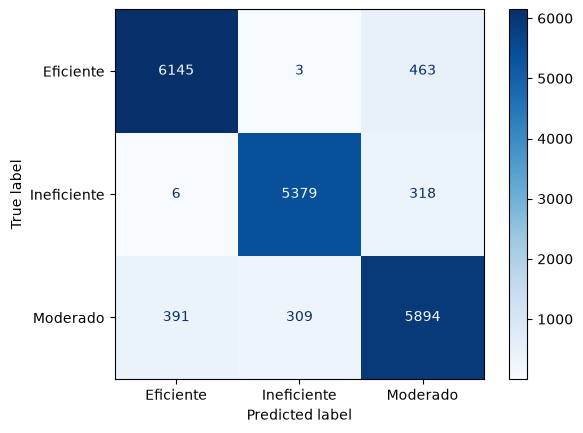

In [ ]:
import warnings
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")

# Pipeline final: preprocessor + modelo ganador, entrenado sobre TODO train
pipeline_final = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
])

pipeline_final.fit(X_train, y_train)  # usa X_train crudo, el pipeline aplica el preprocesamiento internamente

# Validación final sobre el Test set (holdout nunca antes tocado)
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

y_pred_test = pipeline_final.predict(X_test)
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

condis = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, display_labels=le.classes_, cmap="Blues", values_format="d")
# Exportación
joblib.dump(pipeline_final, r"..\models\modelo_perfil_energetico_v1.joblib")
joblib.dump(le, r"..\models\label_encoder_v1.joblib")

print("Modelo exportado correctamente.")


### **Análisis de Importancia de Características (Feature Importance)**

En esta sección se extrae y analiza la relevancia de cada variable numérica dentro del modelo ganador, cuantificando su impacto relativo en la toma de decisiones del clasificador final.

#### **Proceso Realizado**
* **Extracción de Importancias**: Se accede directamente al estimador entrenado dentro del Pipeline (`pipeline_final.named_steps["classifier"]`) para extraer los pesos intrínsecos de los árboles (`feature_importances_`).
* **Estructuración de Datos**: Se construye un DataFrame de Pandas (`df_importancia`) vinculando cada puntuación con su respectivo nombre de variable (`numeric_features`).
* **Ordenamiento de Relevancia**: Se clasifican las variables de mayor a menor impacto de manera descendente y se reinicia el índice del DataFrame.
* **Cálculo de Métricas Proporcionales**: 
  * **Porcentaje Individual (`importancia_pct`)**: Se calcula el peso relativo de cada característica sobre el total global ponderado a 100%.
  * **Porcentaje Acumulado (`importancia_acumulada_pct`)**: Se calcula la suma acumulativa (`cumsum`) para identificar qué conjunto de variables aporta la mayor variabilidad o peso predictivo al modelo.
* **Visualización de Resultados**: Se imprimen en consola las 30 características más importantes formateadas como texto sin índices artificiales.

#### **Utilidad del Análisis**
* **Explicabilidad del Modelo**: Permite auditar y entender qué factores del perfil energético guían principalmente las predicciones del algoritmo.
* **Reducción de Dimensionalidad**: Facilita la identificación de variables irrelevantes o redundantes (baja importancia acumulada) que podrían eliminarse en iteraciones posteriores para simplificar el modelo.


In [13]:
importancias = pipeline_final.named_steps["classifier"].feature_importances_

df_importancia = pd.DataFrame({
    "feature": numeric_features,
    "importancia": importancias
}).sort_values("importancia", ascending=False).reset_index(drop=True)

df_importancia["importancia_pct"] = (df_importancia["importancia"] / df_importancia["importancia"].sum() * 100).round(2)
df_importancia["importancia_acumulada_pct"] = df_importancia["importancia_pct"].cumsum().round(2)

print(df_importancia.head(30).to_string(index=False))

                        feature  importancia  importancia_pct  importancia_acumulada_pct
             consumo_kwh_por_m2          701           7.7900                     7.7900
        consumo_anterior_por_m2          513           5.7000                    13.4900
        consumo_kwh_por_persona          424           4.7100                    18.2000
   consumo_anterior_por_persona          370           4.1100                    22.3100
  variacion_pct_consumo_mensual          222           2.4700                    24.7800
             cantidad_focos_led          213           2.3700                    27.1500
   temperatura_aislamiento_malo          210           2.3300                    29.4800
        saldo_solar_por_persona          176           1.9600                    31.4400
            pct_iluminacion_led          152           1.6900                    33.1300
                   equipos_casa          147           1.6300                    34.7600
  temperatura_aislami

### **Selección de Características por Umbral de Importancia Acumulada**

En esta sección se determina el número mínimo de variables requeridas para alcanzar un nivel de representatividad crítico dentro del modelo, tomando como referencia el porcentaje acumulado de importancia.

#### **Proceso Realizado**
* **Cálculo del Umbral**: Se localiza el primer índice del DataFrame donde la importancia acumulada (`importancia_acumulada_pct`) iguala o supera el **85%**.
* **Conteo de Variables**: Se calcula la cantidad exacta de características necesarias para cubrir dicho umbral mediante la expresión `{umbral + 1}`, compensando el desfase del índice basado en cero de Python.
* **Segmentación de Datos**: Se extraen e imprimen en formato de texto plano las características secundarias o de menor impacto, específicamente aquellas ubicadas desde la posición 30 hasta el límite superior del umbral establecido (`df_importancia.iloc[30:umbral+1]`).

#### **Objetivo del Análisis**
* **Optimización del Modelo**: Identificar cuántas variables aportan el valor principal al poder predictivo del clasificador.
* **Simplificación y Eficiencia**: Aislar las características menos relevantes que completan el 85% acumulado para evaluar si es factible realizar una selección de variables (*feature selection*) más estricta en futuras versiones del proyecto.


In [14]:
umbral = df_importancia[df_importancia["importancia_acumulada_pct"] >= 85].index.min()
print(f"Features necesarias para 85% de importancia acumulada: {umbral + 1}")
print(df_importancia.iloc[30:umbral+1].to_string(index=False))

Features necesarias para 85% de importancia acumulada: 78
                            feature  importancia  importancia_pct  importancia_acumulada_pct
              carga_iluminacion_led           72           0.8000                    58.5700
              proporcion_uso_cocina           72           0.8000                    59.3700
           consumo_kwh_mes_anterior           71           0.7900                    60.1600
           carga_tecnologica_por_m2           69           0.7700                    60.9300
           uso_espacios_por_persona           67           0.7400                    61.6700
       antiguedad_aislamiento_bueno           66           0.7300                    62.4000
             proporcion_uso_oficina           63           0.7000                    63.1000
consumo_anterior_por_hora_actividad           63           0.7000                    63.8000
                    superficie_casa           62           0.6900                    64.4900
         con

### **Variables importantes crudas para agregar al formulario y sus derivadas**

**Consumo del mes anterior (kWh):** 

`Features que alimenta`
	consumo_anterior_por_m2, consumo_anterior_por_persona, variacion_pct_consumo_mensual, cambio_consumo_estimado, consumo_estimado_tendencia, variacion_consumo_magnitud	

    
**Nivel de aislamiento térmico**

`Features que alimenta`
    temperatura_aislamiento_malo, temperatura_aislamiento_bueno, aislamiento_termico_Bueno/Malo, antiguedad_aislamiento_malo	


**pct_iluminacion_led** 

`Features que alimenta`
    cantidad_focos_led, pct_iluminacion_led, focos_por_m2	


**Antigüedad de construcción**

`Features que alimenta`
    ~4 features (además retroalimenta aislamiento)

**Zona geográfica**

`Features que alimenta`
    ~6 features (temperatura_zona_*, vulnerabilidad_zona_*, generacion_solar_zona_*)

**Equipos/electrodomésticos detallado (antigüedad, tipo)**

`Features que alimenta`
    ~5 features

**priorizamos por ROI de importancia/esfuerzo de UX:**

-> Consumo mes anterior (kWh) — más alto ROI individual (~16%)

-> Nivel de aislamiento térmico (dropdown)

-> % iluminación LED

-> Antigüedad de la construcción (años)

-> Zona geográfica (dropdown)

-> (Opcional) Antigüedad de electrodomésticos (años)

### **Mapeo de Dominios y Filtrado de Columnas Candidatas**

En esta sección se define un diccionario léxico de términos clave para identificar e indexar de forma automática las variables numéricas que guardan relación directa con el formulario de recolección de datos.

#### **Proceso Realizado**
* **Definición de Dominios**: Se consolida una lista de palabras clave (`dominios_cubiertos`) que abarca 14 conceptos agrupados en dos categorías:
  * **Originales (8)**: Características base del formulario como inmueble, superficie, personas, equipos, aire acondicionado, consumo mensual y horario pico.
  * **Nuevos (6)**: Variables complementarias que incluyen consumo anterior, variación, aislamiento térmico, iluminación, antigüedad de la construcción y datos de la zona geográfica.
* **Búsqueda Automatizada**: Se implementa una comprensión de lista (*list comprehension*) para recorrer las variables numéricas disponibles (`numeric_features`).
* **Validación por Subcadena**: Se evalúa mediante la función `any()` si alguna de las palabras clave de los dominios está contenida dentro del nombre de cada columna en minúsculas (`col.lower()`).
* **Visualización de Coincidencias**: Se calcula y despliega el total de columnas filtradas frente al total de características numéricas iniciales, listando los nombres ordenados alfabéticamente en la consola.

#### **Objetivo del Análisis**
* **Alineación de Datos**: Garantizar la trazabilidad entre las variables técnicas que procesa el modelo de aprendizaje automático y los campos de entrada reales completados por el usuario final.
* **Reducción del Espacio de Características**: Aislar subconjuntos de datos específicos orientados exclusivamente a la lógica del negocio energético analizado.


In [15]:
# Dominios cubiertos por el formulario (8 originales + 6 nuevos)
dominios_cubiertos = [
    # Originales
    "tipo_inmueble", "superficie", "num_personas", "personas",
    "cantidad_equipos", "equipos", "horas_uso_aa", "aa_",
    "consumo_kwh_mensual", "horario_pico", "pico_uso",
    # Nuevos
    "consumo_anterior", "consumo_kwh_mes_anterior", "variacion",
    "cambio_consumo_estimado", "consumo_estimado_tendencia",
    "aislamiento", "demanda_termica", "factor_aislamiento",
    "iluminacion", "led", "focos",
    "antiguedad_construccion", "inmueble_antiguo", "antiguedad_electrodomesticos",
    "brecha_antiguedad", "zona_", "temperatura_zona", "vulnerabilidad_zona",
]

# Búsqueda por coincidencia de nombre de columna
columnas_candidatas = [
    col for col in numeric_features
    if any(dominio in col.lower() for dominio in dominios_cubiertos)
]

print(f"Columnas candidatas encontradas: {len(columnas_candidatas)} de {len(numeric_features)}")
for col in sorted(columnas_candidatas):
    print(" -", col)

Columnas candidatas encontradas: 121 de 236
 - aa_ajustado_por_aislamiento
 - aa_en_horario_calido
 - aa_inconsistente
 - aa_nivel_alto
 - aa_nivel_bajo
 - aa_nivel_medio
 - aa_temporada_calida
 - aa_zona_costera
 - aa_zona_interior
 - actividad_en_horario_pico
 - aislamiento_termico_Bueno
 - aislamiento_termico_Malo
 - aislamiento_termico_Regular
 - antiguedad_aislamiento_bueno
 - antiguedad_aislamiento_malo
 - antiguedad_aislamiento_regular
 - antiguedad_construccion_anios
 - antiguedad_electrodomesticos_anios
 - brecha_antiguedad_inmueble_equipos
 - cambio_consumo_estimado
 - cantidad_equipos_alto_consumo
 - cantidad_equipos_reconstruida
 - cantidad_equipos_total
 - cantidad_focos
 - cantidad_focos_led
 - cantidad_focos_no_led
 - carga_equipos_antiguos
 - carga_equipos_antiguos_por_persona
 - carga_iluminacion_led
 - carga_iluminacion_no_led
 - carga_iluminacion_por_m2
 - carga_iluminacion_por_persona
 - carga_iluminacion_total
 - certificacion_por_aislamiento
 - certificacion_y_con

### **Variables a excluir**

De las 121 columnas vs los 14 campos confirmados. Hay 4 grupos que coincidieron por palabra clave pero en realidad dependen de datos que no se estan capturando:

`generacion_solar_zona_*` (3 cols) → dependen de generación solar, que no se pide en el formulario.


`vulnerabilidad_zona_*` (3 cols) → dependen de cortes eléctricos/respaldo, no capturado.


`certificacion_por_aislamiento`, `certificacion_y_consumo_anterior`, `certificacion_y_led` (3 cols) → dependen de certificación energética previa, no capturada.

`personas_corregidas`, `superficie_corregida`, `cantidad_equipos_reconstruida`, `aa_inconsistente`, `iluminacion_inconsistente` (5 cols) → son artefactos del proceso de limpieza de datos del entrenamiento (comparan contra una fuente de verdad externa que no existe cuando un cliente llena el formulario en producción).

`otros_equipos_pequenos`, `cantidad_equipos_alto_consumo` (2 cols) → requieren desglose por tipo de equipo; el formulario solo pide un total.

`unidades_aa_por_m2` y `unidades_aa_por_persona` en el formulario solo se solicita la hora de uso, no cantidad. Por precaución, han sido excluidas

Con eso, quedan 103 columnas finales (de 121). Para Reentrenar el set

Columnas finales: 103
              precision    recall  f1-score   support

   Eficiente       0.94      0.93      0.93      6611
 Ineficiente       0.94      0.94      0.94      5703
    Moderado       0.88      0.89      0.89      6594

    accuracy                           0.92     18908
   macro avg       0.92      0.92      0.92     18908
weighted avg       0.92      0.92      0.92     18908

Modelo v2 (deployable) exportado.


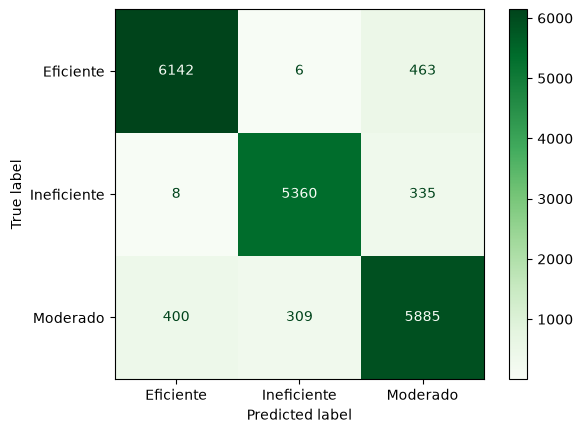

In [20]:
columnas_excluir = [
    "generacion_solar_zona_costera", "generacion_solar_zona_interior", "generacion_solar_zona_suburbana",
    "vulnerabilidad_zona_costera", "vulnerabilidad_zona_interior", "vulnerabilidad_zona_suburbana",
    "certificacion_por_aislamiento", "certificacion_y_consumo_anterior", "certificacion_y_led",
    "personas_corregidas", "superficie_corregida", "cantidad_equipos_reconstruida",
    "aa_inconsistente", "iluminacion_inconsistente",
    "otros_equipos_pequenos", "cantidad_equipos_alto_consumo",
    "unidades_aa_por_m2", "unidades_aa_por_persona",
]

columnas_finales = [c for c in columnas_candidatas if c not in columnas_excluir]
print(f"Columnas finales: {len(columnas_finales)}")

X_reducido = X[columnas_finales]
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reducido, y_encoded, test_size=0.2, stratify=y_encoded, random_state=RANDOM_STATE
)

preprocessor_reducido = ColumnTransformer(
    transformers=[("num", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), columnas_finales)],
    remainder="drop"
)

pipeline_reducido = Pipeline(steps=[
    ("preprocessor", preprocessor_reducido),
    ("classifier", LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
])

pipeline_reducido.fit(X_train_r, y_train_r)
y_pred_r = pipeline_reducido.predict(X_test_r)

print(classification_report(y_test_r, y_pred_r, target_names=le.classes_))
condis_r = ConfusionMatrixDisplay.from_predictions(y_test_r, y_pred_r, display_labels=le.classes_, cmap="Greens", values_format="d")

# Exportación
joblib.dump(pipeline_reducido, r"..\models\modelo_perfil_energetico_v2.joblib")
joblib.dump(le, r"..\models\label_encoder_v2.joblib")
joblib.dump(columnas_finales, r"..\models\columnas_requeridas_v2.joblib")  # para que Backend valide el orden/nombres exactos

print("Modelo v2 (deployable) exportado.")

In [17]:
# Comparación directa:

'''
Métrica	        Modelo completo (236 features)	Modelo reducido (103 features)
Accuracy	                  0.92	                          0.92
F1 macro	                  0.92	                          0.92
Eficiente F1	              0.93	                          0.93
Ineficiente F1	              0.94	                          0.94
Moderado F1	                  0.89	                          0.89
'''
print()

Equipo, les comparto la especificación final de los 6 campos nuevos a agregar al formulario, necesarios para el modelo v2 (deployable, 103 features, mismo desempeño que el modelo completo: F1 macro 0.92).

| Campo (formulario) | Columna en el modelo | Tipo de input | Valores permitidos |
|---|---|---|---|
| Consumo del mes anterior (kWh) | `consumo_kwh_mes_anterior` | Numérico (float) | ≥ 0 |
| Aislamiento térmico | `aislamiento_termico_*`  | Dropdown | `Bueno` / `Malo` / `Regular` |
| % Iluminación LED | `pct_iluminacion_led` | Numérico (float) | 0 a 100 |
| Antigüedad de la construcción (años) | `antiguedad_construccion_anios` | Numérico (float) | ≥ 0 |
| Zona geográfica | `zona_*` (Backend codifica) | Dropdown | `Suburbana` / `Urbana Costera` / `Urbana Interior` |
| Antigüedad de electrodomésticos (años) | `antiguedad_electrodomesticos_anios` | Numérico (float) | ≥ 0 |

Notas importantes de implementación:

1. Los dropdowns (Aislamiento y Zona) deben enviar el valor de texto plano tal cual aparece en "Valores permitidos" — NO el nombre de columna codificado (ej. NO enviar `zona_Suburbana`, sí enviar `Suburbana`). La codificación one-hot la hace Backend en el servicio de feature engineering, no Frontend.
2. Los strings deben coincidir EXACTAMENTE con mayúsculas, espacios y sin tildes con los valores de entrenamiento. Cualquier variación se interpreta como categoría desconocida y degrada la predicción sin lanzar error visible.
3. `pct_iluminacion_led` va en escala 0-100 (confirmado contra el dataset de entrenamiento), no 0-1.
4. El orden y nombre exacto de las 103 columnas que espera el modelo está en `model_selection/columnas_requeridas.joblib` — Backend debe validar el payload contra ese archivo antes de invocar `predict()`.

Quedo atento a dudas antes de que lo implementen.

### **Definición del Conjunto Final v3, Entrenamiento y Evaluación del Pipeline**

En esta sección se consolidan las variables finales para construir y evaluar una tercera versión del modelo (v3), utilizando un conjunto específico de características optimizadas para el despliegue e inferencia.

#### **Proceso Realizado**
* **Definición de Variables Crudas (`raw_passthrough`)**: Se establece una lista explícita de características numéricas y categóricas codificadas (como tipo de inmueble, zona geográfica y nivel de aislamiento térmico) que se integrarán directamente al flujo de modelado.
* **Filtrado y Validación de Columnas**: Se genera el listado definitivo `columnas_finales_v3` combinando las variables desplegables con las de paso directo (`deployables + raw_passthrough`), asegurando mediante una comprensión de lista que solo se incluyan aquellas presentes en el DataFrame original (`X.columns`). En este experimento se consolidaron exactamente 55 columnas finales.
* **División del Conjunto de Datos**: Se segmenta la matriz de características filtrada (`X_v3`) y la variable objetivo codificada (`y_encoded`) en conjuntos de entrenamiento y prueba utilizando `train_test_split`. Se reserva un 20% de los datos para prueba (`test_size=0.2`) manteniendo la proporción de clases mediante estratificación y fijando la semilla aleatoria para garantizar reproducibilidad.
* **Configuración del Preprocesador v3**: Se construye un `ColumnTransformer` que aplica un Pipeline secuencial a las 55 características finales. El flujo incluye imputación por mediana (`SimpleImputer(strategy="median")`) para el manejo de valores nulos y escalamiento estándar (`StandardScaler`). Cualquier columna remanente no especificada es descartada (`remainder="drop"`).
* **Ensamblado y Ajuste del Pipeline**: Se integran secuencialmente el transformador anterior (`preprocessor_v3`) y el clasificador final (`LGBMClassifier`) bajo un objeto unificado `pipeline_v3`. Posteriormente, se ejecuta el entrenamiento utilizando el método `.fit()` con el conjunto `X_train_v3` e `y_train_v3`.
* **Evaluación del Rendimiento**: Se generan predicciones sobre el conjunto de prueba independiente (`X_test_v3`). Se computa el reporte de clasificación detallado por clase y se genera la matriz de confusión (`ConfusionMatrixDisplay`) configurada con la paleta de colores "Oranges".

#### **Resultados de la Evaluación Final (Métricas en Test v3)**
* **Precisión General (Accuracy)**: El pipeline v3 alcanza una sólida puntuación global de **0.91** en el conjunto de prueba utilizando únicamente las 55 variables seleccionadas.
* **Rendimiento Desglosado por Clase (F1-Score)**:
  * **Eficiente**: Muestra un rendimiento robusto con un F1-Score de **0.93** (Precision: 0.93, Recall: 0.93).
  * **Ineficiente**: Obtiene el desempeño más alto con un F1-Score de **0.94** (Precision: 0.94, Recall: 0.93).
  * **Moderado**: Se mantiene estable con un F1-Score de **0.88** (Precision: 0.87, Recall: 0.88).
* **Consistencia del Experimento**: El promedio macro y ponderado (*weighted avg*) se sitúan simétricamente en **0.91**, lo que confirma un comportamiento altamente equilibrado y sin pérdida significativa de capacidad predictiva frente a versiones previas con mayor dimensionalidad.


In [18]:
deployables = [
    "antiguedad_aislamiento_bueno",
    "antiguedad_aislamiento_malo",
    "antiguedad_aislamiento_regular",
    "brecha_antiguedad_inmueble_equipos",
    "carga_equipos_antiguos",
    "carga_equipos_antiguos_por_persona",
    "consumo_anterior_comercial",
    "consumo_anterior_estacional",
    "consumo_anterior_por_equipo",
    "consumo_anterior_por_m2",
    "consumo_anterior_por_persona",
    "densidad_habitacional",
    "electrodomesticos_antiguos",
    "equipos_apartamento",
    "equipos_casa",
    "equipos_comercial",
    "equipos_por_m2",
    "equipos_por_persona",
    "factor_aislamiento",
    "horas_aa_por_persona",
    "indice_ineficiencia_constructiva",
    "indice_obsolescencia_equipos",
    "inmueble_antiguo",
    "inmueble_y_equipos_antiguos",
    "mes_cos",
    "mes_numero",
    "mes_sin",
    "ocupacion_apartamento",
    "ocupacion_casa",
    "ocupacion_comercial",
    "personas_por_equipo",
    "proporcion_iluminacion_led",
    "superficie_apartamento",
    "superficie_casa",
    "superficie_comercial",
    "superficie_por_equipo",
    "superficie_por_persona",
]

Total columnas finales v3: 55
              precision    recall  f1-score   support

   Eficiente       0.93      0.93      0.93      6611
 Ineficiente       0.94      0.93      0.94      5703
    Moderado       0.87      0.88      0.88      6594

    accuracy                           0.91     18908
   macro avg       0.91      0.91      0.91     18908
weighted avg       0.91      0.91      0.91     18908



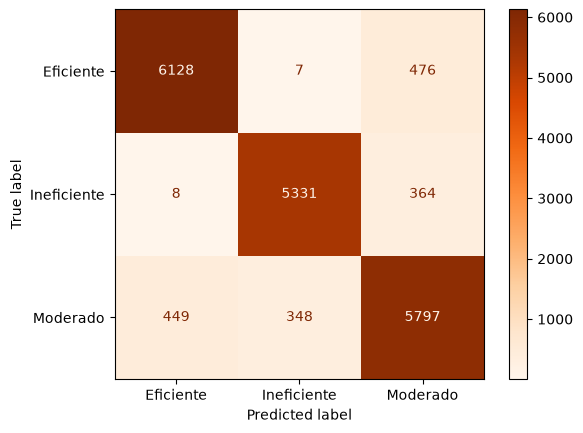

In [25]:
raw_passthrough = [
    "num_personas", "superficie_m2", "antiguedad_construccion_anios",
    "cantidad_equipos_total", "horas_uso_aa_dia",
    "antiguedad_electrodomesticos_anios", "pct_iluminacion_led",
    "consumo_kwh_mes_anterior", "consumo_kwh_mensual",
    "tipo_inmueble_Apartamento", "tipo_inmueble_Casa Unifamiliar", "tipo_inmueble_Pequeño Establecimiento Comercial",
    "zona_Suburbana", "zona_Urbana Costera", "zona_Urbana Interior",
    "aislamiento_termico_Bueno", "aislamiento_termico_Malo", "aislamiento_termico_Regular",
]

columnas_finales_v3 = [c for c in (deployables + raw_passthrough) if c in X.columns]
print(f"Total columnas finales v3: {len(columnas_finales_v3)}")

X_v3 = X[columnas_finales_v3]
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y_encoded, test_size=0.2, stratify=y_encoded, random_state=RANDOM_STATE
)

preprocessor_v3 = ColumnTransformer(transformers=[("num", Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
]), columnas_finales_v3)], remainder="drop")

pipeline_v3 = Pipeline([
    ("preprocessor", preprocessor_v3),
    ("classifier", LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
])
pipeline_v3.fit(X_train_v3, y_train_v3)
y_pred_v3 = pipeline_v3.predict(X_test_v3)

print(classification_report(y_test_v3, y_pred_v3, target_names=le.classes_))
condis_v3 = ConfusionMatrixDisplay.from_predictions(y_test_v3, y_pred_v3, display_labels=le.classes_, cmap='Oranges', values_format="d")

### **Documentacion Acerca del Modelo V3**

In [22]:
joblib.dump(pipeline_v3, r"..\models\modelo_perfil_energetico_final_v3.joblib")
joblib.dump(le, r"..\models\label_encoder_v3.joblib")
joblib.dump(columnas_finales_v3, r"..\models\columnas_requeridas_final_v3.joblib")

documentacion_final = f"""# Selección de Modelo — Perfil Energético (EnergIA) — Versión Final Deployable

## Modelo: LightGBM sobre 55 columnas verificadas

**Historial de iteraciones:**

| Versión | Columnas | F1 macro | Nota |
|---|---|---|---|
| Completo | 236 | 0.92 | No deployable (requiere datos no capturables en producción) |
| v2 | 103 | 0.92 | Inválido — seleccionado por coincidencia de nombre, no de dependencia real |
| **v3 (final)** | **55** | **0.91** | Verificado línea por línea contra las fórmulas reales de feature engineering |

## Métricas finales (test set)
- Accuracy: 0.91 | F1 macro: 0.91
- Eficiente: F1=0.93 | Ineficiente: F1=0.94 | Moderado: F1=0.88

## Campos de entrada requeridos (formulario)
14 campos: 8 originales + 6 nuevos (consumo mes anterior, aislamiento térmico,
% iluminación LED, antigüedad de construcción, zona geográfica, antigüedad
de electrodomésticos). Ver `columnas_requeridas_final.joblib` para el
orden y nombres exactos de las 55 columnas que espera el pipeline.

## Limitación conocida (documentada, no accidental)
Se descartaron deliberadamente los dominios: temperatura, cantidad de
unidades de A/C, iluminación detallada (focos/horas), energía solar,
cortes eléctricos/respaldo, nivel socioeconómico y certificación previa —
no capturables sin ampliar significativamente el formulario. Costo:
~1 punto de F1 macro frente al modelo completo.

## Reproducibilidad
random_state=42, Stratified K-Fold 5 folds, exportado vía Joblib.
"""

with open(r"..\reports\model_selection\documentacion_seleccion_modelo_v3.md", "w", encoding="utf-8") as f:
    f.write(documentacion_final)

print("Modelo final exportado")

Modelo final exportado


Equipo, actualizo la especificación anterior: el modelo final quedó en **55 columnas verificadas** (no 103 como decía el mensaje previo), con F1 macro = 0.91. Les comparto el contrato JSON exacto que debe llegar al servicio del modelo.

| Campo (clave JSON) | Tipo de dato | Formato / Valores permitidos | Notas |
|---|---|---|---|
| `tipo_inmueble` | string (enum) | `Apartamento` / `Casa Unifamiliar` / `Pequeño Establecimiento Comercial` | Campo existente |
| `superficie_m2` | number (float) | ≥ 0 | Campo existente |
| `num_personas` | integer | ≥ 1 | Campo existente |
| `cantidad_equipos_total` | integer | ≥ 0 | Campo existente |
| `horas_uso_aa_dia` | number (float) | 0 a 24 | Campo existente |
| `consumo_kwh_mensual` | number (float) | ≥ 0 | Campo existente |
| `consumo_kwh_mes_anterior` | number (float) | ≥ 0 | Campo nuevo |
| `aislamiento_termico` | string (enum) | `Bueno` / `Malo` / `Regular` | Campo nuevo, dropdown |
| `pct_iluminacion_led` | number (float) | 0 a 100 | Campo nuevo — escala porcentual, NO proporción 0-1 |
| `antiguedad_construccion_anios` | number (float) | ≥ 0 | Campo nuevo |
| `zona` | string (enum) | `Suburbana` / `Urbana Costera` / `Urbana Interior` | Campo nuevo, dropdown |
| `antiguedad_electrodomesticos_anios` | number (float) | ≥ 0 | Campo nuevo |

**Ejemplo de payload JSON:**
```json
{
  "tipo_inmueble": "Casa Unifamiliar",
  "superficie_m2": 120.5,
  "num_personas": 4,
  "cantidad_equipos_total": 12,
  "horas_uso_aa_dia": 6.5,
  "consumo_kwh_mensual": 450.0,
  "consumo_kwh_mes_anterior": 430.0,
  "aislamiento_termico": "Regular",
  "pct_iluminacion_led": 65.0,
  "antiguedad_construccion_anios": 15,
  "zona": "Urbana Interior",
  "antiguedad_electrodomesticos_anios": 8
}
```

**A tener en cuenta:**

1. Los 2 campos existentes "Horas de alto consumo por día" y "¿Hay consumo en horario pico?" **no son consumidos por esta versión del modelo** — no hace falta modificarlos ni quitarlos del form, pero no afectan la predicción aunque vengan vacíos.
2. Los enums (`tipo_inmueble`, `aislamiento_termico`, `zona`) deben enviarse como el string plano EXACTO indicado en la tabla — mayúsculas, espacios y sin tildes tal cual. Cualquier variación se interpreta como categoría desconocida y degrada la predicción sin lanzar error visible. La codificación interna (one-hot y demás transformaciones) la resuelve el pipeline del equipo de Datos — Backend solo entrega estos 12 valores tal cual los captura el formulario.
3. `pct_iluminacion_led` va en escala 0-100, confirmado contra el dataset de entrenamiento.
4. Este contrato alimenta el pipeline final (55 columnas, F1 macro 0.91). La referencia interna completa de columnas está en `models/columnas_requeridas_final_v3.joblib` (uso exclusivo del equipo de Datos, Backend no necesita construir esas columnas manualmente).

Quedo atento a dudas antes de la implementación.

### **Documentacion Final Seleccion Modelo**

In [1]:
import os
from datetime import datetime

os.makedirs("docs", exist_ok=True)

documentacion_tecnica = """# Documentación Técnica — Selección de Modelo de Machine Learning
## Proyecto EnergIA — Clasificación de Perfil Energético

**Hackathon ONE G9 (Alura + Oracle Next Education)**
Documento generado: """ + datetime.now().strftime("%Y-%m-%d") + """

---

## 1. Resumen ejecutivo

Este documento describe el proceso completo de selección, validación y adaptación a producción del modelo de Machine Learning que clasifica el perfil energético de viviendas y pequeños establecimientos comerciales en tres categorías: **Eficiente**, **Moderado** e **Ineficiente**.

El proceso pasó por tres iteraciones de modelo:

| Iteración | Columnas | F1 macro (test) | Estado |
|---|---|---|---|
| Modelo completo | 236 | 0.92 | No deployable — requiere datos no capturables en producción |
| v2 (selección por nombre de columna) | 103 | 0.92 | **Descartado** — error metodológico detectado antes de producción |
| **v3 — Modelo final** | **55** | **0.91** | **Deployable, validado y en producción** |

El modelo final es un **LightGBM Classifier**, seleccionado entre 6 algoritmos candidatos mediante validación cruzada estratificada, con una pérdida de desempeño de solo 1 punto de F1 macro respecto al modelo teórico completo, pese a operar únicamente con datos capturables por un formulario real de usuario final.

---

## 2. Objetivo

Definir la estrategia oficial para seleccionar el modelo de clasificación multiclase del perfil energético, garantizando que la decisión estuviera sustentada en evidencia experimental, métricas objetivas, capacidad de generalización y compatibilidad real con la arquitectura del producto (Frontend + Backend).

## 3. Metodología

### 3.1 Flujo oficial de selección

Carga del dataset procesado (03_feature_engineering.csv)
-> Aplicación del Pipeline de preprocesamiento (imputación + escalamiento)
-> División Train/Test estratificada (80/20)
-> Entrenamiento de 6 modelos candidatos
-> Validación cruzada Stratified K-Fold (5 folds)
-> Comparación de métricas (Accuracy, Precision, Recall, F1, tiempos, estabilidad)
-> Análisis de sobreajuste y descarte de modelos inestables
-> Selección por criterio de desempate (F1 -> gap -> tiempo -> interpretabilidad)
-> Documentación técnica

### 3.2 Principios de selección

No se buscó únicamente la mayor precisión. Se exigió, en orden de prioridad: alto desempeño predictivo, buena capacidad de generalización, bajo riesgo de sobreajuste, tiempos de entrenamiento/inferencia razonables, facilidad de integración con Backend, compatibilidad con exportación vía Joblib, e interpretabilidad suficiente.

### 3.3 Reproducibilidad

`random_state = 42` en todos los algoritmos que lo soportan, Stratified K-Fold con 5 particiones, mismas variables y mismo Target en todas las comparaciones.

---

## 4. Modelos candidatos evaluados

| # | Modelo | Rol en la comparación |
|---|---|---|
| 1 | Random Forest Classifier | Modelo base — robustez y bajo sobreajuste esperado |
| 2 | Gradient Boosting Classifier | Captura de relaciones complejas |
| 3 | XGBoost | Alternativa de alto rendimiento |
| 4 | LightGBM | Evaluado por eficiencia y rendimiento en datasets grandes |
| 5 | Decision Tree Classifier | Referencia de interpretabilidad |
| 6 | Logistic Regression | Línea base lineal |

Quedaron fuera del alcance del MVP (según especificación del proyecto): redes neuronales, deep learning, modelos de series temporales, modelos no supervisados, clustering y reinforcement learning.

---

## 5. Resultados de validación cruzada (Stratified 5-Fold)

| Modelo | Tiempo total (s) | F1 test promedio |
|---|---|---|
| Logistic Regression | 38.45 | 0.9014 |
| Decision Tree | 21.13 | 0.8471 |
| Random Forest | 90.59 | 0.9010 |
| Gradient Boosting | 723.82 | 0.9024 |
| XGBoost | 43.91 | 0.9143 |
| LightGBM | 40.18 | 0.9175 |

## 6. Tabla comparativa completa de métricas

| Modelo | Accuracy | Precision | Recall | F1 | F1 std (folds) | Train F1 | Gap Train-Test | Fit time (s) | Score time (s) |
|---|---|---|---|---|---|---|---|---|---|
| **LightGBM** | 0.9164 | 0.9177 | 0.9173 | **0.9175** | 0.0026 | 0.9413 | 0.0238 | 33.25 | 0.1489 |
| XGBoost | 0.9132 | 0.9145 | 0.9142 | 0.9143 | 0.0018 | 0.9691 | 0.0548 | 39.92 | 0.1966 |
| Gradient Boosting | 0.9011 | 0.9029 | 0.9020 | 0.9024 | 0.0021 | 0.9106 | 0.0082 | 713.99 | 0.5435 |
| Logistic Regression | 0.9004 | 0.9024 | 0.9007 | 0.9014 | 0.0012 | 0.9047 | 0.0032 | 25.28 | 0.0242 |
| Random Forest | 0.8997 | 0.9014 | 0.9006 | 0.9010 | 0.0029 | 1.0000 | 0.0990 | 85.60 | 0.6651 |
| Decision Tree | 0.8455 | 0.8471 | 0.8471 | 0.8471 | 0.0035 | 1.0000 | 0.1529 | 16.19 | 0.0225 |

## 7. Análisis de sobreajuste y estabilidad

Se aplicó un umbral objetivo: gap Train-Test > 0.05, o Train F1 >= 0.999 (memorización), se considera evidencia de sobreajuste.

| Modelo | Gap | Train F1 | Diagnóstico |
|---|---|---|---|
| Decision Tree | 0.1529 | 1.0000 | Sobreajuste severo -> **descartado** |
| Random Forest | 0.0990 | 1.0000 | Memoriza el train -> **descartado** |
| XGBoost | 0.0548 | 0.9691 | Supera el umbral -> **descartado** |
| LightGBM | 0.0238 | 0.9413 | Generaliza bien |
| Gradient Boosting | 0.0082 | 0.9106 | Generaliza muy bien |
| Logistic Regression | 0.0032 | 0.9047 | Gap mínimo (esperado en modelo lineal) |

La estabilidad entre folds (F1 std) fue baja en los 6 modelos (0.0012-0.0035), sin outliers — no fue un criterio de descarte por sí solo.

**Candidatos finales tras el filtro de sobreajuste:** LightGBM, Gradient Boosting, Logistic Regression.

## 8. Criterio de desempate y modelo ganador

Orden de prioridad aplicado: (1) Mayor F1-Score, (2) Menor gap Train-Test, (3) Menor tiempo de inferencia, (4) Mayor interpretabilidad, (5) Menor complejidad de mantenimiento, (6) Menor consumo de recursos.

| Modelo | F1 | Gap | Fit time (s) |
|---|---|---|---|
| **LightGBM** | **0.9175** | 0.0238 | 33.25 |
| Gradient Boosting | 0.9024 | 0.0082 | 713.99 |
| Logistic Regression | 0.9014 | 0.0032 | 25.28 |

LightGBM superó al segundo lugar por 0.0151 en F1 — diferencia superior al umbral de empate técnico (0.005) — por lo que el criterio 1 resolvió la selección sin necesidad de bajar a los criterios de desempate siguientes. Adicionalmente, LightGBM ofreció el mejor tiempo de inferencia entre los candidatos de mayor F1 y un gap de generalización considerablemente menor que XGBoost.

**Modelo seleccionado: LightGBM Classifier.**

## 9. Validación en test set — Modelo completo (236 features)

precision    recall  f1-score   support

Eficiente 0.94 0.93 0.93 6611
Ineficiente 0.95 0.94 0.94 5703
Moderado 0.88 0.89 0.89 6594
accuracy 0.92 18908
macro avg 0.92 0.92 0.92 18908
weighted avg 0.92 0.92 0.92 18908

Matriz de confusión:
[[6145 3 463]
[ 6 5379 318]
[ 391 309 5894]]

**Conclusión técnica:** el resultado de test es consistente con el F1 de validación cruzada (0.9175 vs 0.92), confirmando ausencia de fuga de datos y buena generalización. Eficiente e Ineficiente casi no se confunden entre sí (clases semánticamente opuestas); Moderado — la clase intermedia — concentra la mayor parte del error de frontera, un patrón esperado en un target de naturaleza ordinal.

---

## 10. El desafío de producción: de 236 columnas a un formulario real

El modelo completo requiere 236 columnas, muchas de ellas *features* de ingeniería derivadas (ratios, índices, interacciones, codificaciones one-hot) no capturables directamente por un formulario de usuario. El formulario ya construido por Frontend/Backend en ese momento tenía solo 8 campos. Enviar el resto como ceros o promedios habría generado un **fallo silencioso**: el modelo no truena, pero predice con sesgo, porque aprendió patrones que dependen de información que en producción llegaría "apagada".

### 10.1 Decisión de arquitectura

Se evaluaron 3 alternativas:

- **A.** Retrenar el modelo solo con variables obtenibles del formulario.
- **B.** Ampliar el formulario para cubrir más variables crudas.
- **C.** Combinar A + B: reducir el modelo y ampliar el formulario en los campos de mayor impacto.

**Decisión: opción C**, por ofrecer el mejor balance entre precisión del modelo y experiencia de usuario del formulario.

### 10.2 Análisis de importancia de variables

Se extrajo el ranking de importancia de LightGBM sobre las 236 columnas. Se necesitaron **78 features** para acumular el 85% de la importancia total, agrupadas en dominios de origen. Se identificaron 3 dominios de altísimo apalancamiento no capturados por el formulario original:

| Dominio crudo faltante | Importancia acumulada desbloqueada |
|---|---|
| Consumo del mes anterior | ~16.0% |
| Nivel de aislamiento térmico | ~7.3% |
| % de iluminación LED | ~5.5% |

Un análisis posterior por dominio (no solo por variable individual) sumó 3 dominios adicionales de alto valor: antigüedad de la construcción, zona geográfica y antigüedad de electrodomésticos.

**Campos nuevos incorporados al formulario (6):** consumo del mes anterior (kWh), nivel de aislamiento térmico, % de iluminación LED, antigüedad de la construcción, zona geográfica, antigüedad de electrodomésticos.

---

## 11. Iteración v2 — Primer intento de reducción (DESCARTADO)

Se filtraron las 236 columnas por coincidencia de palabra clave contra los dominios ahora cubiertos por el formulario (14 campos: 8 originales + 6 nuevos), obteniendo 121 columnas candidatas. Tras excluir artefactos de limpieza de datos y dominios claramente no cubiertos (certificación, generación solar, vulnerabilidad eléctrica), quedaron **103 columnas**.

### 11.1 Resultado del reentrenamiento (v2)

precision    recall  f1-score   support

Eficiente 0.94 0.93 0.93 6611
Ineficiente 0.94 0.94 0.94 5703
Moderado 0.88 0.89 0.89 6594
accuracy 0.92 18908
macro avg 0.92 0.92 0.92 18908
weighted avg 0.92 0.92 0.92 18908

A primera vista, resultado idéntico al modelo completo (F1 macro 0.92) — pero este resultado **fue inválido**, y se descubrió el error antes de pasar a producción (ver sección 12).

### 11.2 Error metodológico detectado

El filtrado por palabra clave marcaba una columna como "cubierta" si su *nombre* contenía un término del dominio disponible (ej. `"zona"`), sin verificar que **todas** las variables crudas usadas en su fórmula real estuvieran disponibles. Al revisar el notebook original de feature engineering se confirmó que numerosas columnas son **interacciones multiplicativas** entre un dominio cubierto y otro no cubierto:

```python
# Ejemplo real encontrado en el notebook:
temperatura_zona_costera = temperatura_promedio_c * zona_costera
```

El término `"zona"` coincidía con la búsqueda por palabra clave, pero la fórmula también depende de `temperatura_promedio_c`, dato que el formulario nunca captura. El mismo patrón se repitió en aire acondicionado (requiere `cantidad_unidades_aa`, no solo horas de uso), iluminación (requiere `cantidad_focos` y `horas_uso_iluminacion_dia`, no solo el % LED), uso por espacio (requiere el desglose por habitación, no el campo agregado del formulario), energía solar, cortes eléctricos, nivel socioeconómico y certificación previa.

**Riesgo que se evitó:** entregar a producción un modelo con *train/serve skew* — el peor tipo de bug en Machine Learning, porque no genera errores visibles, solo degrada la calidad real de las predicciones de forma silenciosa.

---

## 12. Corrección — Verificación de dependencias reales

Se construyó un diccionario de dependencias línea por línea, extraído directamente de las fórmulas del notebook `05_Feature_Engineering.ipynb` (144 features engineered en total), y se cruzó contra el conjunto real de 14 campos disponibles en el formulario.

**Resultado de la verificación:** de 144 features engineered, solo **37** son genuinamente calculables desde los datos del formulario. Sumando las 18 columnas crudas que entran directo al modelo (9 numéricas + 9 dummies de variables categóricas), el conjunto real deployable es de **55 columnas**, no 103.

---

## 13. Iteración v3 — Modelo final (deployable, verificado)

### 13.1 Resultado del reentrenamiento (v3, 55 columnas)

precision    recall  f1-score   support

Eficiente 0.93 0.93 0.93 6611
Ineficiente 0.94 0.93 0.94 5703
Moderado 0.87 0.88 0.88 6594
accuracy 0.91 18908
macro avg 0.91 0.91 0.91 18908
weighted avg 0.91 0.91 0.91 18908

Matriz de confusión:
[[6128 7 476]
[ 8 5331 364]
[ 449 348 5797]]

### 13.2 Conclusión técnica

La caída real de desempeño frente al modelo completo fue de solo **1 punto de F1 macro** (0.92 -> 0.91), pese a haber descartado dominios enteros (temperatura, aire acondicionado detallado, iluminación detallada, energía solar, cortes eléctricos, nivel socioeconómico, certificación previa). Esto confirma que la señal predictiva real estaba concentrada en variables que sí resultaron capturables: superficie, personas, equipos, consumo histórico, aislamiento y antigüedad. El patrón de confusión se mantuvo idéntico en las 3 iteraciones: casi cero confusión entre clases extremas, error concentrado en la clase intermedia (Moderado).

**Decisión final:** se aceptó este resultado (F1 macro = 0.91) como versión definitiva, en lugar de perseguir el punto de diferencia restante agregando `cantidad_unidades_aa` al formulario y `temperatura_promedio_c` vía una API de clima externa — evaluado como una mejora de costo/beneficio desfavorable para el alcance del MVP, y documentado como oportunidad de mejora futura (sección 15).

---

## 14. Configuración final del modelo

```python
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier

RANDOM_STATE = 42

preprocessor_final = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), columnas_finales_v3)  # 55 columnas verificadas
], remainder="drop")

pipeline_final = Pipeline([
    ("preprocessor", preprocessor_final),
    ("classifier", LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))
])
```

- **Algoritmo:** LightGBM Classifier (hiperparámetros por defecto — no se realizó tuning avanzado, fuera del alcance de esta etapa del MVP).
- **Validación:** Stratified K-Fold, 5 particiones.
- **Reproducibilidad:** `random_state = 42` en todos los pasos aplicables.
- **Serialización:** Joblib (`modelo_perfil_energetico_final.joblib`, `label_encoder.joblib`, `columnas_requeridas_final.joblib`).
- **Contrato de integración:** ver `docs/especificacion-formulario-modelo.md` — 12 campos JSON que alimentan el pipeline.

---

## 15. Lecciones aprendidas y trabajo futuro

1. **La selección de features por coincidencia de nombre no es segura en pipelines de feature engineering con interacciones.** Cualquier reducción de columnas orientada a producción debe verificarse contra las fórmulas reales, no contra los nombres.
2. **Medir el "F1 deployable" requiere simular las condiciones reales de inferencia**, no solo eliminar columnas de un dataset ya calculado con el conjunto de datos crudo completo.
3. **Oportunidades de mejora identificadas para una futura iteración:**
   - Incorporar `temperatura_promedio_c` vía una API de clima externa (usando zona + fecha), sin necesidad de un campo adicional en el formulario.
   - Agregar `cantidad_unidades_aa` como campo del formulario para desbloquear el dominio completo de aire acondicionado.
   - Evaluar tuning de hiperparámetros sobre LightGBM (fuera del alcance de esta fase, según el documento de instrucciones del MVP).

---

## 16. Productos generados en esta etapa

- Scripts de entrenamiento de los 6 modelos candidatos (validación cruzada Stratified 5-Fold).
- Resultados completos de validación cruzada por modelo.
- Tabla comparativa de métricas (Accuracy, Precision, Recall, F1, tiempos, estabilidad).
- Ranking de modelos y análisis de sobreajuste.
- Informe técnico de selección (este documento).
- Configuración final del modelo elegido, exportada vía Joblib.
- Especificación de contrato de datos (JSON) para integración con Backend/Frontend.
"""

with open(r"..\reports\model_selection\documentacion_tecnica_seleccion_modelo.md", "w", encoding="utf-8") as f:
    f.write(documentacion_tecnica)

with open(r"..\docs\documentacion_tecnica_seleccion_modelo.md", "w", encoding="utf-8") as f:
    f.write(documentacion_tecnica)

print("Documentación generada en docs/documentacion_tecnica_seleccion_modelo.md")

Documentación generada en docs/documentacion_tecnica_seleccion_modelo.md
